# Glass Classification Project

### CPS 285
### By Elianne Nishimwe 

 Dataset from Kaggle: UCI Machine Learning Repository. (n.d.). *Glass Classification Dataset*. Kaggle. Retrieved from https://www.kaggle.com/datasets/uciml/glass


 This project analyzes a glass classification dataset using Python to understand how chemical properties relate to different types of glass. It involves data cleaning and visualization to identify key features and evaluate how well glass types can be predicted.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Data cleaning

In [2]:
df = pd.read_csv('glass.csv')
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


### Keep only relevant columns and renaming columns
- I selected only the relevant columns from the dataset and renamed them, and gave them more descriptive names to make the data easier to understand and analyze. This step is part of the data preprocessing stage in a data pipeline. 


In [3]:
# Keep only relevant columns
df = df[['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']]

# Rename columns to cleaner names
df = df.rename(columns={
    'RI': 'Refractive_Index',
    'Na': 'Sodium',
    'Mg': 'Magnesium',
    'Al': 'Aluminum',
    'Si': 'Silicon',
    'K': 'Potassium',
    'Ca': 'Calcium',
    'Ba': 'Barium',
    'Fe': 'Iron'
})

print("After renaming:\n", df.head())

After renaming:
    Refractive_Index  Sodium  Magnesium  Aluminum  Silicon  Potassium  Calcium  \
0           1.52101   13.64       4.49      1.10    71.78       0.06     8.75   
1           1.51761   13.89       3.60      1.36    72.73       0.48     7.83   
2           1.51618   13.53       3.55      1.54    72.99       0.39     7.78   
3           1.51766   13.21       3.69      1.29    72.61       0.57     8.22   
4           1.51742   13.27       3.62      1.24    73.08       0.55     8.07   

   Barium  Iron  Type  
0     0.0   0.0     1  
1     0.0   0.0     1  
2     0.0   0.0     1  
3     0.0   0.0     1  
4     0.0   0.0     1  


## Visualizations and Anylitical questions

### Distribution of Glass Types
- I created a count plot to visualize the distribution of different glass types and see how many samples belong to each category .


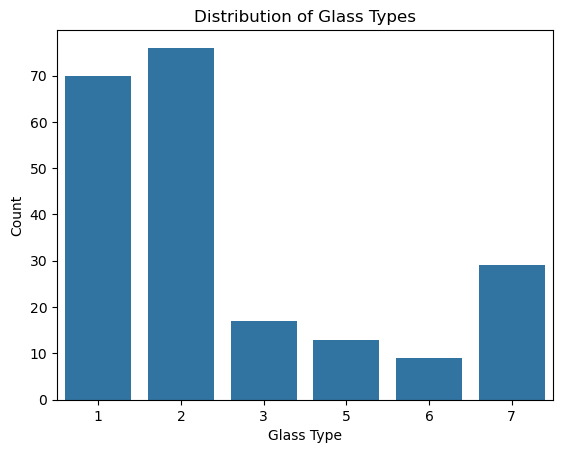

In [4]:
# Distribution of Glass Types
plt.figure()
sns.countplot(data=df, x='Type')
plt.title('Distribution of Glass Types')
plt.xlabel('Glass Type')
plt.ylabel('Count')
plt.show()

### Correlation Heatmap
### What relationship exist between the chemicals?
The heatmap shows the correlation between chemical components in the glass dataset. The target variable (Type) was excluded to focus only on relationships between features.

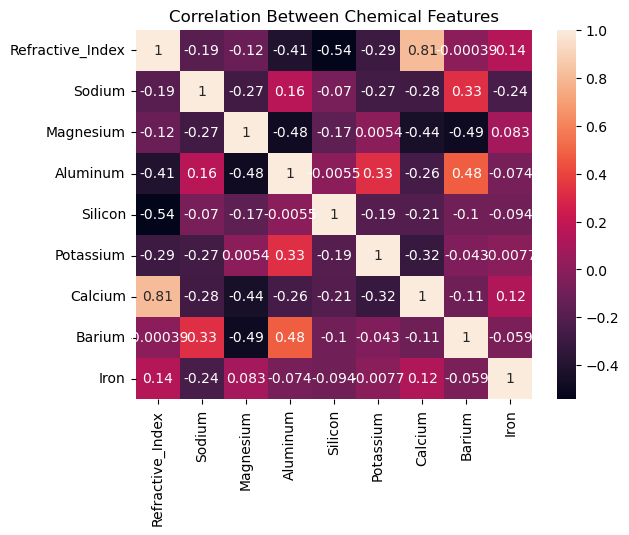

In [5]:
plt.figure()
sns.heatmap(df.drop('Type', axis=1).corr(), annot=True)
plt.title('Correlation Between Chemical Features')
plt.show()

This heatmap shows how the different features relate to each other. The colors represent how strong the relationship is between two variables, with darker colors meaning a stronger connection. It helps make it easier to see patterns and understand which features are more closely related.

### Distribution of Sodium in Glass Dataset

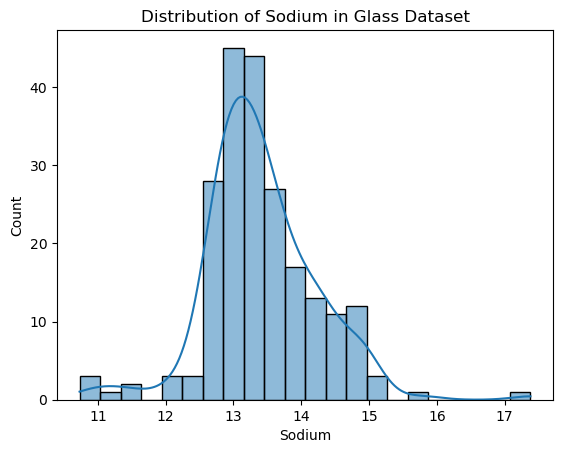

In [6]:
plt.figure()
sns.histplot(df['Sodium'], kde=True)
plt.title("Distribution of Sodium in Glass Dataset")
plt.show()

This plot shows how Sodium values are distributed in the dataset. Most of the values fall within a certain range, which suggests that Sodium levels don’t vary too much between samples. The curve also helps show the overall pattern of the data and whether it is evenly spread out or slightly skewed.

### Which chemical features best distinguish different types of glass? 
- I grouped the data set by glass type. Then calculated the average and median for each feature. This helps compare chemical properties across different glass types. Different glass types have different chemical compositions, these differneces help distingush glass. 

In [7]:
# Group by glass type
grouped_mean = df.groupby('Type').mean()
grouped_median = df.groupby('Type').median()

print("\nMean values by glass type:\n", grouped_mean)
print("\nMedian values by glass type:\n", grouped_median)



Mean values by glass type:
       Refractive_Index     Sodium  Magnesium  Aluminum    Silicon  Potassium  \
Type                                                                           
1             1.518718  13.242286   3.552429  1.163857  72.619143   0.447429   
2             1.518619  13.111711   3.002105  1.408158  72.598026   0.521053   
3             1.517964  13.437059   3.543529  1.201176  72.404706   0.406471   
5             1.518928  12.827692   0.773846  2.033846  72.366154   1.470000   
6             1.517456  14.646667   1.305556  1.366667  73.206667   0.000000   
7             1.517116  14.442069   0.538276  2.122759  72.965862   0.325172   

        Calcium    Barium      Iron  
Type                                 
1      8.797286  0.012714  0.057000  
2      9.073684  0.050263  0.079737  
3      8.782941  0.008824  0.057059  
5     10.123846  0.187692  0.060769  
6      9.356667  0.000000  0.000000  
7      8.491379  1.040000  0.013448  

Median values by glass ty

The results show that certain features, such as Sodium, Magnesium, Aluminum, and Calcium, differ noticeably between glass types. These differences in values indicate that each type of glass has a unique chemical profile. By comparing these averages, it becomes easier to identify which features contribute the most to distinguishing one glass type from another.

### Which glass type has the most variation in its features?
- I calculated the standard deviation for glass type. This shows how much the values vary within each group.
- Why does it matter? a higher standard deviation means the values are more spread out and a lower value means the data is more consistant. 

In [8]:
# Calculate the standard deviation for glass types
grouped_std = df.groupby('Type').std()
print("\nStandard deviation by glass type:\n", grouped_std)



Standard deviation by glass type:
       Refractive_Index    Sodium  Magnesium  Aluminum   Silicon  Potassium  \
Type                                                                         
1             0.002268  0.499301   0.247043  0.273158  0.569484   0.214879   
2             0.003802  0.664159   1.215661  0.318340  0.724573   0.213726   
3             0.001916  0.506887   0.162786  0.347489  0.512276   0.229890   
5             0.003345  0.777037   0.999146  0.693920  1.282319   2.138695   
6             0.003116  1.084020   1.097134  0.571861  1.079467   0.000000   
7             0.002545  0.686359   1.117683  0.442726  0.940234   0.668493   

       Calcium    Barium      Iron  
Type                                
1     0.574807  0.083838  0.089075  
2     1.921635  0.362340  0.106433  
3     0.380111  0.036380  0.107864  
5     2.183791  0.608251  0.155588  
6     1.449948  0.000000  0.000000  
7     0.973505  0.665341  0.029794  


The results show that glass type 7 has the most variation, meaning its chemical values are more spread out compared to the other types. This suggests that type 7 is less consistent, while other glass types have more similar values within their group

### How does these features vary by glass type?
- I used boxplots to visualize how the distribution of key chemical features varies across different glass types. Each boxplot shows the median, spread, and potential outliers for a feature within each category. This helps identify which elements differ significantly between glass types and may be important for classification.

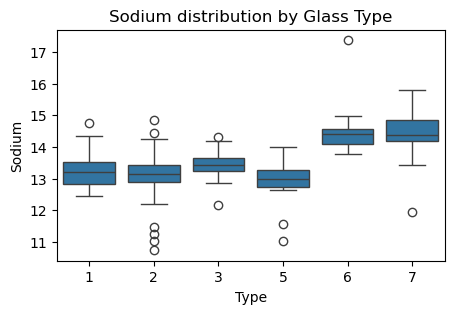

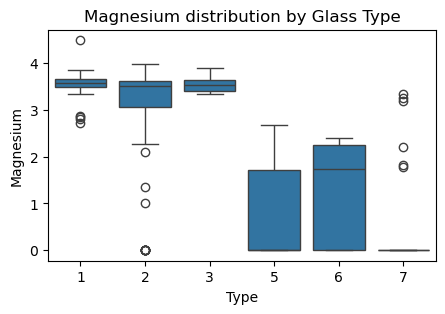

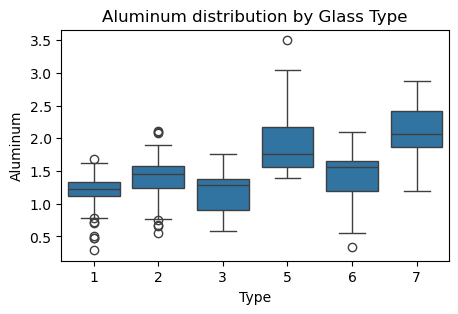

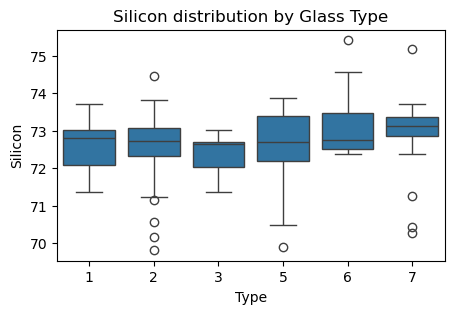

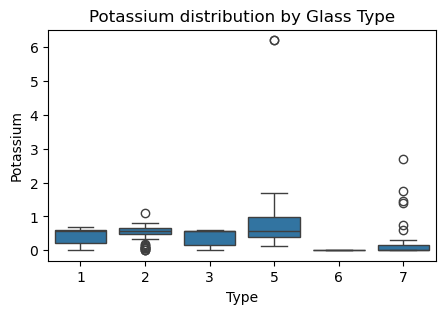

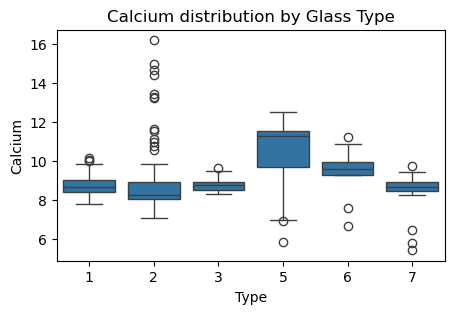

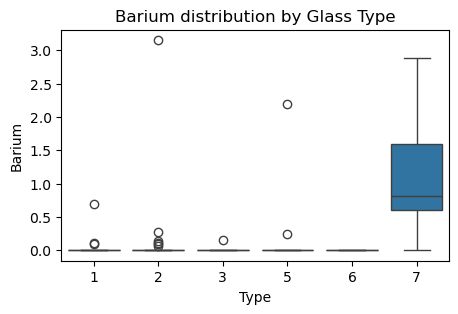

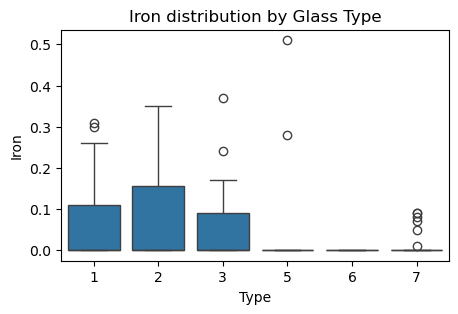

In [9]:
# Boxplots for key features

features = ['Sodium', 'Magnesium', 'Aluminum', 'Silicon', 
            'Potassium', 'Calcium', 'Barium', 'Iron']

for feature in features:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x='Type', y=feature, data=df)
    plt.title(f"{feature} distribution by Glass Type")
    plt.show()

### Can we predict glass type using chemical features?

I built a Logistic Regression model by splitting and scaling the data, then trained it to predict glass type and evaluated its performance using accuracy.
- Yes glass types can be predicted using chemical composition. The Logical Regression model achieved an accuracy of approximately 65%,
  indicating a moderate ability to classify glass types based on their chemical features.

In [10]:
# Features and target
X = df.drop(['Type'], axis=1)
y = df['Type']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6511627906976745


### Which Chemical features are most important in predicting glass type?
- I used a Decision Tree model to calculate feature importance, which shows how much each feature contributes to the prediction. The results show that Aluminum is the most important feature, followed by Barium and Calcium.

In [11]:
# Features and target
X = df.drop(['Type'], axis=1)
y = df['Type']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Get feature importance
importance = model.feature_importances_

# Display results
feature_names = X.columns

for i in range(len(feature_names)):
    print(feature_names[i], ":", importance[i])

Refractive_Index : 0.13303562688701734
Sodium : 0.08667449414061988
Magnesium : 0.1756425118216963
Aluminum : 0.21788302758868544
Silicon : 0.0374384236453202
Potassium : 0.04392238289457423
Calcium : 0.08738597736462034
Barium : 0.17521815622800832
Iron : 0.04279939942945797


### Are there natural clusters of glass types based on their properties?
- I applied K-Means clustering to group similar glass samples and used PCA to reduce the data to two dimensions for visualization, allowing me to see how the samples cluster based on their chemical features
- This visualization shows that glass samples form natural clusters based on their chemical properties, suggesting that the features help group similar types together.

Cluster Summary (Average Feature Values):

         Refractive_Index     Sodium  Magnesium  Aluminum    Silicon  \
Cluster                                                                
0                1.516229  14.532667   0.425000  2.232667  72.822333   
1                1.522572  13.395000   2.046042  1.132917  72.091458   
2                1.517352  13.164265   3.408309  1.381250  72.810588   

         Potassium    Calcium    Barium      Iron      Type  
Cluster                                                      
0         0.649000   8.171333  1.078667  0.013000  6.766667  
1         0.227917  10.862708  0.076250  0.076875  2.770833  
2         0.558529   8.457647  0.010588  0.059706  1.904412  


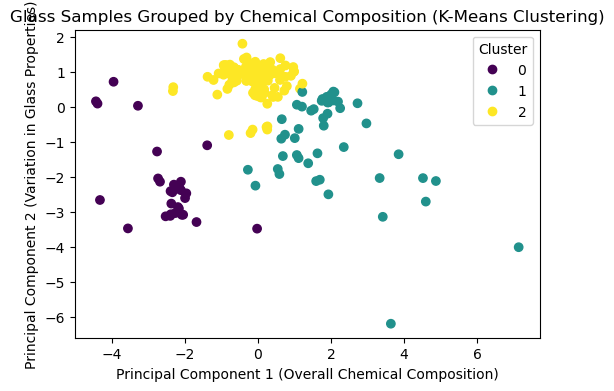

In [13]:
# Features only (drop target)
X = df.drop(['Type'], axis=1)

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = clusters

cluster_summary = df.groupby('Cluster').mean()

print("Cluster Summary (Average Feature Values):\n")
print(cluster_summary)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Scatter Plot
plt.figure(figsize=(6,4))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)

plt.xlabel("Principal Component 1 (Overall Chemical Composition)")
plt.ylabel("Principal Component 2 (Variation in Glass Properties)")
plt.title("Glass Samples Grouped by Chemical Composition (K-Means Clustering)")

# Add legend
plt.legend(*scatter.legend_elements(), title="Cluster")

plt.show()


Each cluster represents a group of glass samples with similar chemical properties. For example, one cluster has low Magnesium and high Aluminum, another has higher Calcium, and another has higher Magnesium. These differences show how the samples are grouped based on their composition.

## Final Summary
In this project, I analyzed a glass dataset to understand how different chemical features relate to glass types. I explored the data using visualizations like histograms and heatmaps and compared groups using summary statistics such as mean and median. I also examined variation using standard deviation and boxplots.

I applied machine learning models, including Logistic Regression and Decision Trees, to predict glass types and identify important features. In addition, I used K-Means clustering and PCA to group similar samples and visualize patterns in the data. Overall, the results showed that features like Sodium, Magnesium, Aluminum, and Calcium play a key role in distinguishing between different types of glass.
